In [1]:
import pandas as pd
import pickle
import numpy as np
import talib
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open('../../data/nifty_data.pkl', 'rb') as file:
    nifty_data = pickle.load(file)

In [3]:
with open('../../data/sp500_data.pkl', 'rb') as file:
    sp500_data = pickle.load(file)
with open('../../data/usdinr_data.pkl', 'rb') as file:
    usdinr_data = pickle.load(file)
with open('../../data/gold_data.pkl', 'rb') as file:
    gold_data = pickle.load(file)
with open('../../data/vix_data.pkl', 'rb') as file:
    vix_data = pickle.load(file)
with open('../../data/nse_bank_data.pkl', 'rb') as file:
    nse_bank_data = pickle.load(file)
with open('../../data/cnx_it_data.pkl', 'rb') as file:
    cnx_it_data = pickle.load(file)

In [4]:
from dataclasses import dataclass
from typing import Dict, Optional
from pydantic import BaseModel, ConfigDict
from typing_extensions import Literal
import enum
import numpy as np
import pandas as pd
import yfinance as yf
import pickle

# create a enum for the stock names
class StockName(enum.Enum):
    NIFTY = "nifty_data"
    SP500 = "sp500_data"
    USDINR = "usdinr_data"
    GOLD = "gold_data"
    VIX = "vix_data"
    NSE_BANK = "nse_bank_data"
    CNX_IT = "cnx_it_data"


stocks = [
    {"name": "nifty_data", "ticker": "^NSEI"},
    {"name": "sp500_data", "ticker": "^GSPC"},
    {"name": "usdinr_data", "ticker": "USDINR=X"},
    {"name": "gold_data", "ticker": "GC=F"},
    {"name": "vix_data", "ticker": "^INDIAVIX"},
    {"name": "nse_bank_data", "ticker": "^NSEBANK"},
    {"name": "cnx_it_data", "ticker": "^CNXIT"},
]

class OHLCVData(BaseModel):
    model_config = ConfigDict(arbitrary_types_allowed=True)

    name: Literal["nifty_data", "sp500_data", "usdinr_data", "gold_data", "vix_data", "nse_bank_data", "cnx_it_data"]
    data: pd.DataFrame

class DataObject(BaseModel):
    model_config = ConfigDict(arbitrary_types_allowed=True)

    nifty_data: OHLCVData
    sp500_data: OHLCVData
    usdinr_data: OHLCVData
    gold_data: OHLCVData
    vix_data: OHLCVData
    nse_bank_data: OHLCVData
    cnx_it_data: OHLCVData

class DataAligner:
    def align(self, all_data: DataObject) -> DataObject:
        base_index = all_data.nifty_data.data.index

        def align_df(df: pd.DataFrame) -> pd.DataFrame:
            aligned = df.reindex(base_index).copy()
            aligned = aligned.ffill()
            return aligned

        fields = [
            "nifty_data",
            "sp500_data",
            "usdinr_data",
            "gold_data",
            "vix_data",
            "nse_bank_data",
            "cnx_it_data",
        ]
        data_dict = {}
        for field in fields:
            ohlcv = getattr(all_data, field)
            data_dict[field] = OHLCVData(
                name=ohlcv.name, data=align_df(ohlcv.data))
        return DataObject(**data_dict)


class YahooFinanceDataLoader:
    def __init__(self, stock: Dict[str, str], use_local: bool = False):
        self.stock = stock
        self.use_local = use_local
        self.data_aligner = DataAligner()

    def load_data(self, ticker: str, start: str, end: str) -> pd.DataFrame:
        return yf.Ticker(ticker).history(start=start, end=end, auto_adjust=True)
    
   
    def clean_data(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df.index = df.index.tz_localize(None)
        df = df[["Close", "Open", "High", "Low", "Volume"]]
        return df
    
    def merge_old_and_new_data(self, old_df: pd.DataFrame, new_df: pd.DataFrame) -> pd.DataFrame:
        combined = pd.concat([old_df, new_df])
        combined = combined[~combined.index.duplicated(keep='last')]
        combined = combined.sort_index()
        return combined
    
    def run(self, start: str|None, end: str|None) -> DataObject:
        data_dict = {}
        for key, ticker in self.stock.items():
            if self.use_local:
                with open(f'../../data/{key}.pkl', 'rb') as file:
                    raw_data = pickle.load(file)
            else:
                raw_data = self.load_data(ticker, start, end)
            cleaned_data = self.clean_data(raw_data)
            data_dict[key] = OHLCVData(name=key, data=cleaned_data)
        # align all data to nifty_data index
        data_object = DataObject(**data_dict)
        aligned_data_object = self.data_aligner.align(data_object)
        return aligned_data_object
    
    

    
FEATURES = [
    "rolling_sharpe_20",
    "rolling_max_dd_60",

    "realized_vol_20",
    "vol_slope_20",

    "autocorr_20",

    "rel_spx_20",
    "usdinr_vol_20",
    "rel_gold_20",
    "vix_level_20",

    "vix_slope_20",
    "trend_strength_200",

    "sector_dispersion_ratio_20",
]

@dataclass(frozen=True)
class FeatureConfig:
    sharpe_window: int = 20
    max_dd_window: int = 60
    vol_window: int = 20
    autocorr_window: int = 20
    rel_window: int = 20
    vix_window: int = 20
    trend_window: int = 200
    sector_window: int = 20
    epsilon: float = 1e-8

class FeatureEngineer:
    def __init__(self, all_data: DataObject, config: FeatureConfig | None = None):
        self.config = config or FeatureConfig()
        self.all_data = all_data
        self.df = self.all_data.nifty_data.data.copy()
        self.div_zero_counts: Dict[str, int] = {}

    
    def _safe_div(self, numerator: pd.Series, denominator: pd.Series, label: str) -> pd.Series:
        zero_mask = denominator == 0
        self.div_zero_counts[label] = int(zero_mask.sum())
        denom = denominator.mask(zero_mask, self.config.epsilon)
        return numerator / denom

    def get_div_zero_counts(self) -> pd.Series:
        return pd.Series(self.div_zero_counts).sort_values(ascending=False)

    def compute_sector_dispersion(self, market_vol: pd.Series) -> pd.Series:
        cfg = self.config
        nse_bank_data = self.all_data.nse_bank_data.data
        cnx_it_data = self.all_data.cnx_it_data.data

        sector_df = pd.DataFrame({
            "nse_bank": nse_bank_data["Close"],
            "cnx_it": cnx_it_data["Close"],
        })
        sector_returns = np.log(sector_df / sector_df.shift(1))
        daily_dispersion = sector_returns.std(axis=1)
        dispersion = daily_dispersion.rolling(cfg.sector_window, min_periods=cfg.sector_window).mean()
        # print null counts for dispersion and market_vol
        # return self._safe_div(dispersion, market_vol, "sector_dispersion_ratio_20")
        return dispersion/market_vol

    def compute_features(self) -> pd.DataFrame:
        cfg = self.config
        df = self.df
        sp500_data = self.all_data.sp500_data.data
        usdinr_data = self.all_data.usdinr_data.data
        gold_data = self.all_data.gold_data.data
        vix_data = self.all_data.vix_data.data

        log_ret = np.log(df["Close"] / df["Close"].shift(1))
        features = pd.DataFrame(index=df.index)

        sharpe_mean = log_ret.rolling(cfg.sharpe_window, min_periods=cfg.sharpe_window).mean()
        sharpe_std = log_ret.rolling(cfg.sharpe_window, min_periods=cfg.sharpe_window).std()
        features["rolling_sharpe_20"] = self._safe_div(sharpe_mean, sharpe_std, "rolling_sharpe_20")

        rolling_max = df["Close"].rolling(cfg.max_dd_window, min_periods=cfg.max_dd_window).max()
        drawdown = df["Close"] / rolling_max - 1.0
        features["rolling_max_dd_60"] = drawdown.rolling(cfg.max_dd_window, min_periods=cfg.max_dd_window).min()

        features["realized_vol_20"] = np.sqrt((log_ret ** 2).rolling(cfg.vol_window, min_periods=cfg.vol_window).sum())
        features["vol_slope_20"] = features["realized_vol_20"].diff()

        features["autocorr_20"] = log_ret.rolling(cfg.autocorr_window, min_periods=cfg.autocorr_window).apply(
            lambda x: x.autocorr(lag=1),
            raw=False,
        )

        features["rel_spx_20"] = (
            np.log(df["Close"] / df["Close"].shift(cfg.rel_window))
            - np.log(sp500_data["Close"] / sp500_data["Close"].shift(cfg.rel_window))
        )
        features["usdinr_vol_20"] = (
            np.log(usdinr_data["Close"] / usdinr_data["Close"].shift(1))
            .rolling(cfg.vol_window, min_periods=cfg.vol_window)
            .std()
        )
        features["rel_gold_20"] = (
            np.log(df["Close"] / df["Close"].shift(cfg.rel_window))
            - np.log(gold_data["Close"] / gold_data["Close"].shift(cfg.rel_window))
        )
        features["vix_level_20"] = vix_data["Close"].rolling(cfg.vix_window, min_periods=cfg.vix_window).mean()
        features["vix_slope_20"] = vix_data["Close"].diff().rolling(cfg.vix_window, min_periods=cfg.vix_window).mean()

        trend_mean = df["Close"].rolling(cfg.trend_window, min_periods=cfg.trend_window).mean()
        trend_std = df["Close"].rolling(cfg.trend_window, min_periods=cfg.trend_window).std()
        features["trend_strength_200"] = self._safe_div(df["Close"] - trend_mean, trend_std, "trend_strength_200")

        market_vol = log_ret.rolling(cfg.sector_window, min_periods=cfg.sector_window).std()
        features["sector_dispersion_ratio_20"] = self.compute_sector_dispersion(market_vol)

        features["Close"] = df["Close"]
        return features


    def run(self) -> pd.DataFrame:
        features = self.compute_features()
        print("Len features before dropping NA:", len(features))
        features = features.dropna()
        print("Len features after dropping NA:", len(features))
        # features = self.standardize_features(features)
        self.save_output(features, '../../data/nifty_features.pkl')
        return features[FEATURES + ["Close"]]
    
    def save_output(self, df: pd.DataFrame, filename: str):

        with open(filename, 'wb') as file:
            pickle.dump(df, file)

class StandardScaler:
    def fit(self, df: pd.DataFrame) -> (pd.Series, pd.Series):
        mean = df.mean()
        std = df.std()
        return mean, std

    def transform(self, df: pd.DataFrame, mean: pd.Series, std: pd.Series) -> pd.DataFrame:
        return (df - mean) / (std + 1e-8)

    def fit_transform(self, df: pd.DataFrame) -> (pd.DataFrame, pd.Series, pd.Series):
        mean, std = self.fit(df)
        scaled_df = self.transform(df, mean, std)
        return scaled_df, mean, std

    def save_output(self, mean: pd.Series, std: pd.Series, feature_list: list[str], filename: str, meta: Optional[dict] = None):
        payload = {
            "mean": mean,
            "std": std,
            "features": feature_list,
            "meta": meta or {},
        }
        with open(filename, 'wb') as file:
            pickle.dump(payload, file)

    def load_output(self, filename: str) -> dict:
        with open(filename, 'rb') as file:
            return pickle.load(file)


In [5]:
data_loader = YahooFinanceDataLoader(stock={stock["name"]: stock["ticker"] for stock in stocks}, use_local=True)
all_data = data_loader.run(start=None, end=None)

In [6]:
feature_engineer = FeatureEngineer(all_data)
df_features = feature_engineer.run()

scaler = StandardScaler()
scaled_features, mean, std = scaler.fit_transform(df_features[FEATURES])

Len features before dropping NA: 4418
Len features after dropping NA: 4219


In [7]:
df_features

,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,vol_slope_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20,Close
Date,,,,,,,,,,,,,
2008-07-07,-0.224338,-0.254667,0.110180,-0.003398,-0.219374,-0.026734,0.002760,-0.146311,32.1885,0.2430,-2.110362,0.448846,4030.000000
2008-07-08,-0.222237,-0.254667,0.110072,-0.000108,-0.215630,-0.045020,0.002833,-0.169792,32.4790,0.2905,-2.162983,0.498549,3988.550049
2008-07-09,-0.160266,-0.254667,0.116441,0.006369,-0.235864,-0.014079,0.002781,-0.137187,32.7105,0.2315,-1.850902,0.452034,4157.100098
2008-07-10,-0.164720,-0.254667,0.116395,-0.000045,-0.194999,-0.020019,0.002684,-0.166004,32.8575,0.1470,-1.824591,0.454354,4162.200195
2008-07-11,-0.203813,-0.254667,0.119516,0.003121,-0.202349,-0.016593,0.003017,-0.206975,32.9730,0.1155,-1.999600,0.500986,4049.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-15,0.164607,-0.049712,0.023662,0.000062,0.116114,-0.004810,0.002324,-0.081356,11.2550,-0.0980,1.037760,1.417814,25069.199219
2025-09-16,0.141348,-0.049712,0.022518,-0.001145,0.016878,-0.009692,0.002375,-0.087393,11.1515,-0.1035,1.215327,1.422829,25239.099609
2025-09-17,0.136405,-0.049712,0.022422,-0.000096,0.038723,-0.015152,0.002390,-0.091529,11.0745,-0.0770,1.302274,1.421272,25330.250000


<Axes: ylabel='Date'>

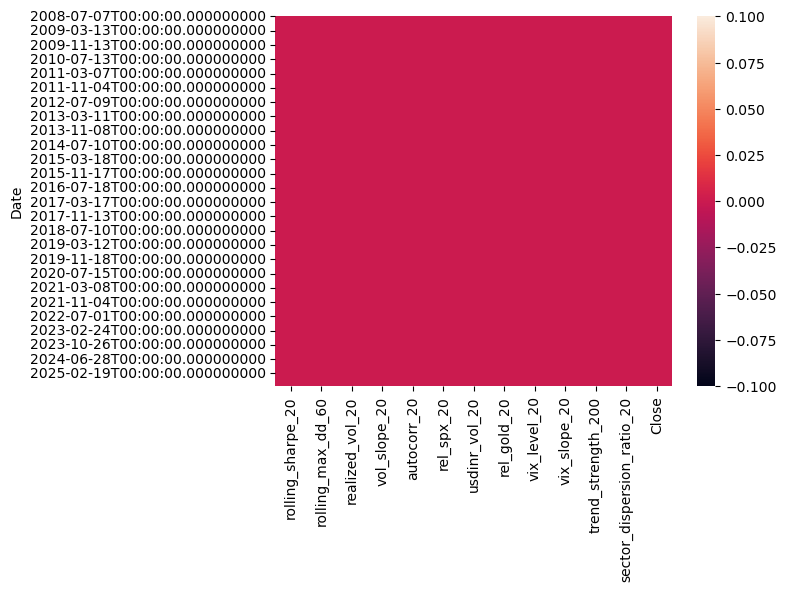

In [8]:
sns.heatmap(df_features.isnull())

In [49]:
df_features["Close"]

Date
2008-07-07     4030.000000
2008-07-08     3988.550049
2008-07-09     4157.100098
2008-07-10     4162.200195
2008-07-11     4049.000000
                  ...     
2025-09-15    25069.199219
2025-09-16    25239.099609
2025-09-17    25330.250000
2025-09-18    25423.599609
2025-09-19    25327.050781
Name: Close, Length: 4219, dtype: float64

In [50]:
with open('../../data/complete_features.pkl', 'wb') as file:
    pickle.dump({
    "scaled_featured": scaled_features,
    "Close": df_features["Close"],
    "mean": mean,
    "std": std,
    }, file)

In [ ]:
# for training I want to save the mean and std of the features so that I can use the same for scaling the test data
# for inference I will load the mean and std from the file and use it for scaling the features
# for training, I want to load old price saved in the file and download latest data from the last date in the old data to today and then merge it with the old data and save it back for feature engineering step. 
# This way I can keep the data updated without losing the old data and also keep the features updated with the latest data.
#  I want to design a pipeline where it can automatically check for the latest date in the old data and download the new data from that date to today and then merge it with the old data and save it back for feature engineering step. This way I can keep the data updated without losing the old data and also keep the features updated with the latest data.



## Inference

In [32]:
# subtract 100 days from 2025-09-19
pd.to_datetime("2025-09-19") - pd.Timedelta(days=200)

Timestamp('2025-03-03 00:00:00')

In [9]:
data_loader = YahooFinanceDataLoader(stock={stock["name"]: stock["ticker"] for stock in stocks})
all_data = data_loader.run(start="2023-12-01", end="2026-05-31")

In [10]:
all_data.nifty_data.data

,Close,Open,High,Low,Volume
Date,,,,,
2023-12-01,20267.900391,20194.099609,20291.550781,20183.699219,265800
2023-12-04,20686.800781,20601.949219,20702.650391,20507.750000,381100
2023-12-05,20855.099609,20808.900391,20864.050781,20711.150391,421000
2023-12-06,20937.699219,20950.750000,20961.949219,20852.150391,359200
2023-12-07,20901.150391,20932.400391,20941.250000,20850.800781,275000
...,...,...,...,...,...
2026-02-13,25471.099609,25571.150391,25630.349609,25444.300781,453500
2026-02-16,25682.750000,25423.599609,25697.000000,25372.699219,275800
2026-02-17,25725.400391,25637.949219,25764.400391,25570.300781,344100


In [11]:
# feature
feature_engineer = FeatureEngineer(all_data)
df_features = feature_engineer.run()

Len features before dropping NA: 549
Len features after dropping NA: 350


In [20]:
last_date = "2025-09-19 00:00:00"
# find the index of the last date in the features dataframe
last_date_index = df_features.index.get_loc(last_date)
last_date_index

246

In [21]:
df_features.iloc[last_date_index-59+1:]

,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,vol_slope_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20,Close
Date,,,,,,,,,,,,,
2025-06-27,0.267670,-0.066457,0.029734,0.000014,0.079110,-0.008050,0.002834,0.039846,14.3870,-0.1845,1.668368,0.909116,25637.800781
2025-06-30,0.237739,-0.066457,0.030075,0.000341,0.030919,-0.012450,0.002862,0.054739,14.1685,-0.2185,1.529964,0.870042,25517.050781
2025-07-01,0.312282,-0.066457,0.029248,-0.000826,0.054180,0.002491,0.002906,0.043948,13.9670,-0.2015,1.548372,0.936557,25541.800781
2025-07-02,0.256118,-0.066457,0.029283,0.000035,0.055106,-0.008797,0.002769,0.040870,13.8020,-0.1650,1.446625,0.960622,25453.400391
2025-07-03,0.201210,-0.066457,0.028862,-0.000421,0.035342,-0.029579,0.002720,0.031813,13.6675,-0.1345,1.395353,0.962085,25405.300781
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,-0.043693,-0.048613,0.037983,0.002239,-0.029796,0.005534,0.004538,-0.089678,12.7895,0.0985,0.329994,1.163316,25471.099609
2026-02-16,-0.002533,-0.048613,0.038858,0.000875,-0.098874,0.014624,0.004534,-0.090748,12.8875,0.0980,0.708909,1.082824,25682.750000
2026-02-17,0.030756,-0.048613,0.038661,-0.000197,-0.141480,0.019498,0.004485,-0.056755,12.9295,0.0420,0.779546,1.109748,25725.400391


In [26]:
new_df = df_features.iloc[last_date_index-59+1:].copy()

new_df

,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,vol_slope_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20,Close
Date,,,,,,,,,,,,,
2025-06-27,0.267670,-0.066457,0.029734,0.000014,0.079110,-0.008050,0.002834,0.039846,14.3870,-0.1845,1.668368,0.909116,25637.800781
2025-06-30,0.237739,-0.066457,0.030075,0.000341,0.030919,-0.012450,0.002862,0.054739,14.1685,-0.2185,1.529964,0.870042,25517.050781
2025-07-01,0.312282,-0.066457,0.029248,-0.000826,0.054180,0.002491,0.002906,0.043948,13.9670,-0.2015,1.548372,0.936557,25541.800781
2025-07-02,0.256118,-0.066457,0.029283,0.000035,0.055106,-0.008797,0.002769,0.040870,13.8020,-0.1650,1.446625,0.960622,25453.400391
2025-07-03,0.201210,-0.066457,0.028862,-0.000421,0.035342,-0.029579,0.002720,0.031813,13.6675,-0.1345,1.395353,0.962085,25405.300781
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,-0.043693,-0.048613,0.037983,0.002239,-0.029796,0.005534,0.004538,-0.089678,12.7895,0.0985,0.329994,1.163316,25471.099609
2026-02-16,-0.002533,-0.048613,0.038858,0.000875,-0.098874,0.014624,0.004534,-0.090748,12.8875,0.0980,0.708909,1.082824,25682.750000
2026-02-17,0.030756,-0.048613,0.038661,-0.000197,-0.141480,0.019498,0.004485,-0.056755,12.9295,0.0420,0.779546,1.109748,25725.400391


In [27]:
# read mean and std from file
scaler = StandardScaler()
with open("../../data/complete_features.pkl", 'rb') as file:
    payload = pickle.load(file)

    mean = payload["mean"]
    std = payload["std"]

scaled_new_features = scaler.transform(new_df[FEATURES], mean, std)

In [28]:
scaled_new_features

,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,vol_slope_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20
Date,,,,,,,,,,,,
2025-06-27,0.798826,0.447462,-0.593711,0.009201,0.356613,-0.200888,-0.542173,0.544669,-0.628762,-0.596476,0.810645,-0.057347
2025-06-30,0.675988,0.447462,-0.582376,0.092789,0.115660,-0.301578,-0.531930,0.757795,-0.653870,-0.709449,0.701643,-0.100755
2025-07-01,0.981913,0.447462,-0.609857,-0.206111,0.231964,0.040351,-0.516026,0.603365,-0.677025,-0.652962,0.716140,-0.026861
2025-07-02,0.751418,0.447462,-0.608705,0.014383,0.236594,-0.217982,-0.565817,0.559314,-0.695986,-0.531682,0.636009,-0.000126
2025-07-03,0.526074,0.447462,-0.622690,-0.102189,0.137778,-0.693584,-0.583572,0.429694,-0.711442,-0.430338,0.595629,0.001498
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,-0.479008,0.668348,-0.319403,0.578947,-0.187915,0.110005,0.076889,-1.308994,-0.812337,0.343861,-0.243405,0.225053
2026-02-16,-0.310087,0.668348,-0.290313,0.229518,-0.533300,0.318026,0.075401,-1.324313,-0.801075,0.342199,0.055013,0.135632
2026-02-17,-0.173470,0.668348,-0.296863,-0.044930,-0.746331,0.429565,0.057481,-0.837821,-0.796249,0.156126,0.110644,0.165542


In [29]:
# save the new scaled features to a file
with open('../../data/new_scaled_features.pkl', 'wb') as file:
    pickle.dump({
        "scaled_features": scaled_new_features,
        "Close": new_df["Close"],
        "mean": payload["mean"],
        "std": payload["std"],
    }, file)